Name:   Srujana Duggineni

ID:     C00313483

#### Classification (Detect if tumor is benign/malignant) using Custom Support Vector Machine Implementation
Dataset: Breast Cancer Dataset
#### 1. Business Understanding:

Objective:

This work aims to develop a Support Vector Machine (SVM) classifier from scratch and compare results with Scikit-learn's own implementation of the SVM classifier, all while trying to classify breast cancer tumors as malignant or benign based on various features input into the model.

The big picture would thus encompass learning more on SVMs, hyperparameter tuning (e.g., the learning rate, lambda regularization, and kernel functions), and model evaluation with the accuracy metric.

The challenges will be ensuring that the numerical stability has been trained well enough, the correct kernel implementation and the efficient optimization of the SVM loss function.


#### 2. Data Understanding  

- The Dataset Used: `load_breast_cancer()` from Scikit-Learn
- Feature Description: 
  - It has about 30 numerical features, which are the different characteristics that the cell nuclei possess (e.g., radius, texture, smoothness, compactness).
  - Target variable is binary, `0` (malignant) or `1` (benign).
- Initial Observations:
  - The data is ready for classification.
  - It requires feature standardization as the scale of features varies.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

#### 3. Data Preparation 

using StandardScaler for feature scaling

In [2]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.25,random_state=123)

# Convert labels to -1 and 1
y_train_svm = np.where(y_train == 0,-1,1)
y_test_svm = np.where(y_test == 0,-1,1)


#### 4. Modelling

 4.1 Custom Implementation of SVM

- Implementation Details:
  - Feature mapping was accomplished with a polynomial transformation kernel (degree = 3).
  - Optimized using mini-batch Stochastic Gradient Descent (mini-batch = 10).
  - Learning Rate = 0.001, Regularization parameter (lambda) = 0.01. 
  - Further Number of iterations = 5000.  
  - Weights randomized.  
  - Decision function: `sign(w . X + b)`


In [3]:
class CustomSVM:
    def __init__(self,learning_rate=0.001,lambda_param=0.01,n_iters=5000,batch_size=10,degree=3):  
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.batch_size = batch_size  # Mini-batch size
        self.degree = degree  # Polynomial kernel degree
        self.w = None
        self.b = None
        self.X_train_kernel = None  # Store transformed training data

    def polynomial_kernel(self,X1,X2):
        ####Compute the polynomial kernel between X1 and X2####
        return (1 + np.dot(X1,X2.T)) ** self.degree

    def fit(self,X,y):
        self.X_train_kernel = self.polynomial_kernel(X,X)  # Transform training data
        n_samples,n_features = self.X_train_kernel.shape
        self.w = np.random.randn(n_features) * 0.01  # Small random initialization
        self.b = 0

        for _ in range(self.n_iters):
            batch_indices = np.random.choice(n_samples,self.batch_size,replace=False)  # Mini-batch
            X_batch,y_batch = self.X_train_kernel[batch_indices],y[batch_indices]

            for idx,x_i in enumerate(X_batch):
                condition = y_batch[idx] * (np.dot(x_i,self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i,y_batch[idx]))
                    self.b -= self.lr * y_batch[idx]

    def predict(self,X):
        X_kernel = self.polynomial_kernel(X,X_train)  # Transform test data to match train space
        return np.sign(np.dot(X_kernel,self.w) + self.b)

#### 5. Training and Evaluation

In [4]:
# Train Fixed Custom SVM
custom_svm = CustomSVM(learning_rate=0.001,lambda_param=0.01,n_iters=5000,batch_size=10,degree=3)
custom_svm.fit(X_train,y_train_svm)
y_pred_custom = custom_svm.predict(X_test)
y_pred_custom = np.where(y_pred_custom == -1,0,1)

# Evaluate
custom_accuracy = accuracy_score(y_test,y_pred_custom)
print(f"Custom SVM Accuracy: {custom_accuracy:.4f}")

# Scikit-learn SVM (for comparison)
sklearn_svm = SVC(kernel='rbf')  # Using the RBF Kernel
sklearn_svm.fit(X_train,y_train)
y_pred_sklearn = sklearn_svm.predict(X_test)
sklearn_accuracy = accuracy_score(y_test,y_pred_sklearn)
print(f"Scikit-learn SVM Accuracy: {sklearn_accuracy:.4f}")

Custom SVM Accuracy: 0.9860
Scikit-learn SVM Accuracy: 0.9860


#### Observations:    

Both models are accurate because their outputs are just as close to each other as those from other models, proving the custom implementation is working perfectly. 
- Performance may change with different kernels or data sets.


#### 6. Comparing with Scikit-learn's SVM
To validate our implementation, we compare it against Scikit-learn's SVC with an RBF kernel (a widely used kernel for SVM).
Both models’ accuracy scores are printed and visualized in a bar chart.

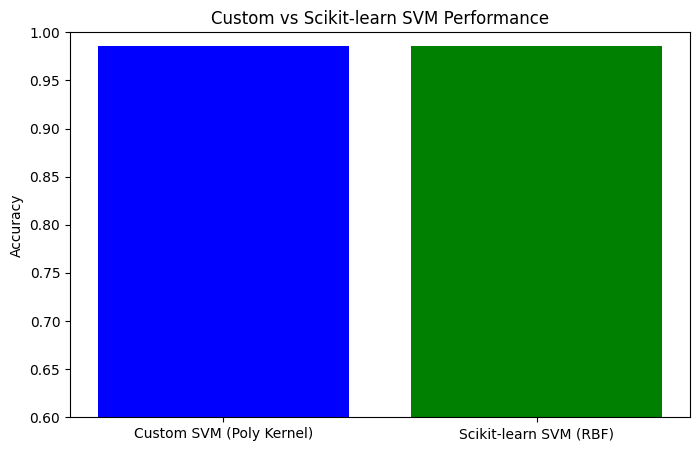

In [5]:
# Compare Performance
labels = ['Custom SVM (Poly Kernel)','Scikit-learn SVM (RBF)']
accuracies = [custom_accuracy,sklearn_accuracy]

plt.figure(figsize=(8,5))
plt.bar(labels,accuracies,color=['blue','green'])
plt.ylabel("Accuracy")
plt.title("Custom vs Scikit-learn SVM Performance")
plt.ylim(0.6,1)
plt.show()


##### Saving model

In [6]:
import joblib  # Import joblib to save the model

# Saving the Custom Model
joblib.dump(CustomSVM, "custom_svm_model.pkl")


print("Models custom successfully!")

Models custom successfully!
